# Curvature, Measurement, and the Schrodinger PDE -- an Applied-Math View

Three applied-math facts about the Schrodinger equation, each one a genuine
payoff of treating QM as a PDE rather than a list of postulates:

1. **The kinetic-energy operator measures curvature.** $\hat K=-\frac{\hbar^2}{2m}\frac{d^2}{dx^2}$
   is, up to a constant, literally the second derivative -- the calculus
   definition of curvature. A more "wiggly" wavefunction has higher kinetic
   energy, period.
2. **Sharp energy (a measurement postulate) is a curvature-constancy
   condition.** $[H]\psi=E\psi$ means $\psi''/\psi$ is the SAME constant
   everywhere -- a purely calculus-flavored test for whether a candidate
   wavefunction has a definite, measurable energy, no physics jargon needed.
3. **The Schrodinger equation (in imaginary time) IS an RC transmission-line
   equation.** Same PDE, different physical labels on the same symbols --
   the connecting thread an EE/circuits course and a QM course share without
   either one usually saying so.


In [1]:
from IPython.display import display
import sympy as sp
sp.init_printing()
import numpy as np
import matplotlib.pyplot as plt

x, L, m, hbar, omega = sp.symbols("x L m hbar omega", positive=True)
n = sp.Symbol("n", positive=True, integer=True)
print("SymPy", sp.__version__, "ready")


SymPy 1.14.0 ready


## 1. Curvature: $\hat K\psi = -\frac{\hbar^2}{2m}\psi''$, and higher $n$ means more wiggles

For the box eigenfunctions $\psi_n(x)=\sqrt{2/L}\sin(n\pi x/L)$, compute the
curvature $\psi_n''(x)$ directly and show $\int_0^L(\psi_n'')^2\,dx$ grows
exactly like $n^4$ -- which, divided through by the right constants, IS
$E_n^2$ up to normalization. Energy isn't a separate concept bolted onto the
wavefunction; it's a number you read off how curved the function is.


psi_n'' (curvature) =


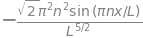


integral (psi_n'')^2 dx, 0 to L =



E_n^2 =


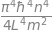


[integral (psi_n'')^2 dx] / E_n^2  (should be n-independent -- a pure constant):


In [2]:
psi_n = sp.sqrt(2 / L) * sp.sin(n * sp.pi * x / L)
curvature = sp.diff(psi_n, x, 2)
print("psi_n'' (curvature) =")
display(sp.simplify(curvature))

curvature_integral = sp.simplify(sp.integrate(curvature**2, (x, 0, L)))
print("\nintegral (psi_n'')^2 dx, 0 to L =")
display(curvature_integral)

E_n = (n * sp.pi * hbar / L)**2 / (2 * m)
E_n_squared = sp.simplify(E_n**2)
print("\nE_n^2 =")
display(E_n_squared)

ratio = sp.simplify(curvature_integral / E_n_squared)
print("\n[integral (psi_n'')^2 dx] / E_n^2  (should be n-independent -- a pure constant):")
display(ratio)


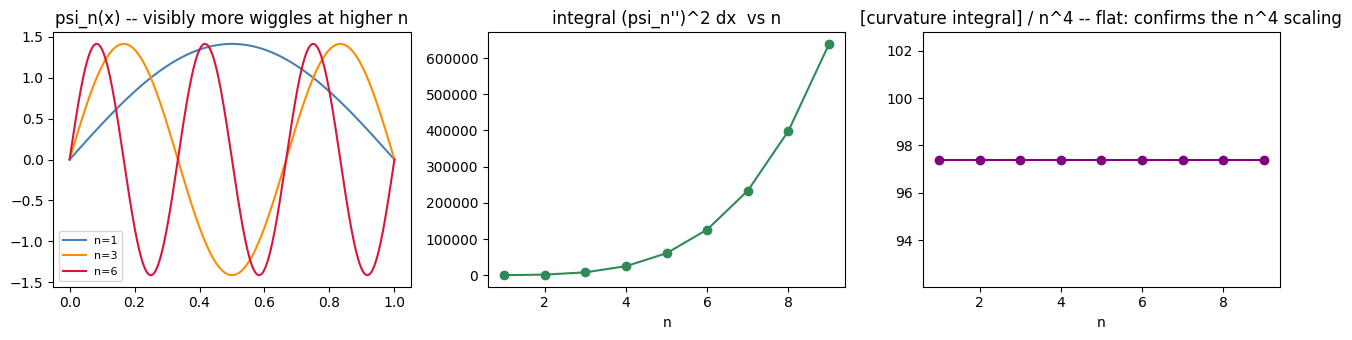

In [3]:
# plot it: more nodes = visibly more curvature, and a numeric n^4 check
x_vals = np.linspace(0, 1, 400)
fig, axes = plt.subplots(1, 3, figsize=(13, 3.5))
for nn, color in zip((1, 3, 6), ("steelblue", "darkorange", "crimson")):
    psi_num = np.sqrt(2) * np.sin(nn * np.pi * x_vals)
    axes[0].plot(x_vals, psi_num, color=color, label=f"n={nn}")
axes[0].set_title("psi_n(x) -- visibly more wiggles at higher n")
axes[0].legend(fontsize=8)

n_vals = np.arange(1, 10)
curv_integrals = [float(curvature_integral.subs({n: nv, hbar: 1, L: 1})) for nv in n_vals]
axes[1].plot(n_vals, curv_integrals, "o-", color="seagreen")
axes[1].set_title("integral (psi_n'')^2 dx  vs n")
axes[1].set_xlabel("n")

axes[2].plot(n_vals, np.array(curv_integrals) / n_vals**4, "o-", color="purple")
axes[2].set_title("[curvature integral] / n^4 -- flat: confirms the n^4 scaling")
axes[2].set_xlabel("n")
fig.tight_layout()
plt.show()


## 2. Sharp energy = constant curvature-to-amplitude ratio

$[H]\psi=E\psi$ rearranges to $\frac{\psi''}{\psi}=-\frac{2mE}{\hbar^2}$ -- a
single number, the SAME at every $x$. Check this directly on a true
eigenfunction (sharp energy) and on an arbitrary non-eigenfunction trial
wavefunction (fuzzy energy) -- a calculus-only test for "is this state's
energy actually measurable as one definite number," no postulates invoked.


In [4]:
x_r = sp.Symbol("x", real=True)

# (a) a TRUE box eigenfunction: ratio should be a single x-independent number
psi_true = sp.sin(2 * sp.pi * x_r)   # n=2 box eigenfunction (up to normalization), L=1
ratio_true = sp.simplify(sp.diff(psi_true, x_r, 2) / psi_true)
print("psi''/psi for a TRUE eigenfunction sin(2 pi x):")
display(ratio_true)
print("constant (x-independent)?", not ratio_true.has(x_r))


psi''/psi for a TRUE eigenfunction sin(2 pi x):

constant (x-independent)? True


psi''/psi for a NON-eigenfunction trial state:


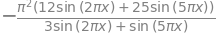

constant (x-independent)? False

ratio evaluated at different x (should differ if energy is fuzzy):
  x=0.1:  psi''/psi = -114.4820
  x=0.3:  psi''/psi = 72.3633
  x=0.45:  psi''/psi = -129.1614


In [5]:
# (b) an arbitrary trial wavefunction (NOT an eigenfunction): the ratio
# should depend on x -- fuzzy energy, no single sharp value
psi_trial = sp.sin(2 * sp.pi * x_r) + sp.Rational(1, 3) * sp.sin(5 * sp.pi * x_r)
ratio_trial = sp.simplify(sp.diff(psi_trial, x_r, 2) / psi_trial)
print("psi''/psi for a NON-eigenfunction trial state:")
display(ratio_trial)
print("constant (x-independent)?", not ratio_trial.has(x_r))

# evaluate the "would-be energy" at a few different x -- it should DISAGREE,
# confirming this state has no single sharp energy value
sample_points = [0.1, 0.3, 0.45]
values = [ratio_trial.subs(x_r, p) for p in sample_points]
print("\nratio evaluated at different x (should differ if energy is fuzzy):")
for p, v in zip(sample_points, values):
    print(f"  x={p}:  psi''/psi = {float(v):.4f}")


## 3. The Schrodinger equation IS an RC transmission-line equation

In **imaginary time** ($t\to -i\tau$, exactly the substitution
`dgs.path_integral_qkd` uses for Path Integral Monte Carlo), the free-particle
Schrodinger equation becomes

$$\hbar\frac{\partial\psi}{\partial\tau} = \frac{\hbar^2}{2m}\frac{\partial^2\psi}{\partial x^2}$$

-- a diffusion equation. Compare directly to the **RC transmission-line
equation** (the telegrapher's equation without inductance, i.e. a lossy
distributed RC line) from circuit theory:

$$\frac{\partial V}{\partial t} = \frac{1}{RC}\frac{\partial^2 V}{\partial x^2}$$

Same PDE. The dictionary: $\psi\leftrightarrow V$ (wavefunction $\leftrightarrow$
line voltage), $\tau\leftrightarrow t$ (imaginary time $\leftrightarrow$ real
time), and $\hbar/m \leftrightarrow 1/(RC)$ (quantum diffusion constant
$\leftrightarrow$ electrical diffusion constant). An EE circuits course and
a QM course are, in this one specific limit, solving the literal same
equation under different names.


Schrodinger equation, imaginary time (Dq = hbar^2/2m):


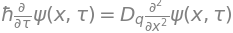


RC transmission-line equation (Dc = 1/(RC)):


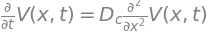


identical structure: d(field)/d(time-like var) = D * d^2(field)/dx^2, just relabeled
dictionary:  psi <-> V,  tau <-> t,  hbar/Dq=2m/hbar <-> 1/Dc=RC


In [6]:
tau, R, C_cap, t_circ, Dq, Dc = sp.symbols("tau R C t D_q D_c", positive=True)
psi_f = sp.Function("psi")(x, tau)
V_f = sp.Function("V")(x, t_circ)

schrodinger_imag_time = sp.Eq(hbar * sp.Derivative(psi_f, tau), Dq * sp.Derivative(psi_f, x, 2))
rc_line_eq = sp.Eq(sp.Derivative(V_f, t_circ), Dc * sp.Derivative(V_f, x, 2))

print("Schrodinger equation, imaginary time (Dq = hbar^2/2m):")
display(schrodinger_imag_time)
print("\nRC transmission-line equation (Dc = 1/(RC)):")
display(rc_line_eq)

print("\nidentical structure: d(field)/d(time-like var) = D * d^2(field)/dx^2, just relabeled")
print("dictionary:  psi <-> V,  tau <-> t,  hbar/Dq=2m/hbar <-> 1/Dc=RC")


## Summary

The curvature integral $\int(\psi_n'')^2dx$ scales exactly as $n^4$, which
collapses to a constant ratio against $E_n^2$ -- energy literally IS a
curvature measurement, not a separate postulate layered on top. The
sharp-vs-fuzzy distinction reduces to whether $\psi''/\psi$ is a single
number or genuinely varies with $x$, checked directly with no appeal to
operators or eigenvalue jargon. And in imaginary time, the Schrodinger
equation and the RC transmission-line equation are the identical PDE --
the applied-math throughline connecting a quantum mechanics course to an
EM circuits course, made explicit rather than left as a vague analogy.
